# Data Understanding 

In [2]:
import pandas as pd
import seaborn as sns
sns.set_palette("pastel")
import plotly.express as px
import matplotlib.pyplot as plt
import math
import numpy as np

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [4]:
df = pd.read_csv("data/plasma_lipidomics.csv")

## 1. Data Analysis

In [5]:
df.head()

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months)
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN


In [75]:
len(df)

212

In [6]:
df.columns

Index(['Sample', 'Diagnostic', 'Sex', 'Age', 'MMSE', 'CSF Amyloid (pg/mL)',
       'CSF Total tau (pg/mL)', 'CSF Phosphorylated tau (pg/mL)', 'APOE4',
       'Progression to Alzheimer's Disease', 'Progression time (months)'],
      dtype='str')

In [10]:
df.describe()

,Sample,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),Progression time (months)
count,212.000000,212.000000,212.000000,198.000000,198.000000,198.000000,47.000000
mean,106.500000,73.485849,25.061321,642.904040,464.257576,79.836364,19.936170
std,61.343296,6.321916,3.013558,381.068117,273.437167,59.701794,12.262357
min,1.000000,52.000000,15.000000,243.000000,67.100000,15.600000,7.000000
25%,53.750000,70.000000,23.000000,420.500000,254.750000,48.025000,12.000000
50%,106.500000,74.000000,25.000000,551.000000,408.500000,68.000000,16.000000
75%,159.250000,78.000000,27.000000,711.750000,613.750000,92.000000,23.500000
max,212.000000,85.000000,30.000000,3863.000000,1550.000000,512.000000,55.000000


In [12]:
def histogram(label,rotation=None):
    ax = sns.histplot(data=df,x=label,hue=label,legend=False, shrink=.9)
    if rotation:
        ax.tick_params(axis='x', labelrotation=rotation)
    # Add the counts on top of each bar automatically
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    image_title = label.replace(" ", "_")
    plt.savefig(f"images/{image_title}", dpi=300, bbox_inches="tight")
    plt.show()

In [13]:
def histogram_totals(totals,title,xlabel):
    labels = ['Yes', 'No']   
    # 2. Create the bar plot
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x=labels, y=totals, palette=['#a1c9f4', '#ffb482'])
    for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    # 3. Add labels and show
    plt.title(title)
    image_title = title.replace(" ", "_")
    plt.savefig(f"images/{image_title}", dpi=300, bbox_inches="tight")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

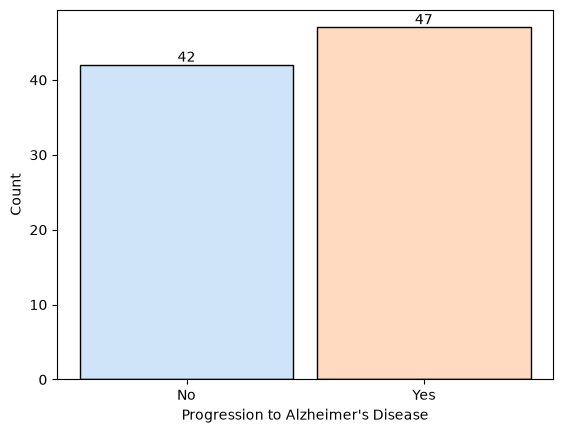

In [14]:
histogram("Progression to Alzheimer's Disease")

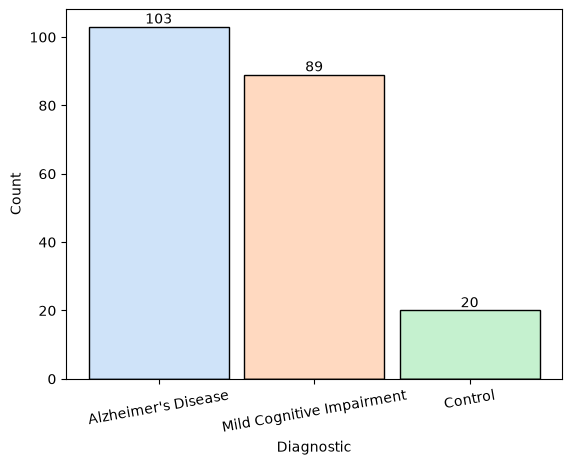

In [15]:
histogram("Diagnostic",rotation=10)

### Exploring the relationships between Diagnostic and the key indicator "Progression to Alzeimers's Disease"

In [16]:
overlap_yes = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 47
Non-MCI patients with Progression = No: 42


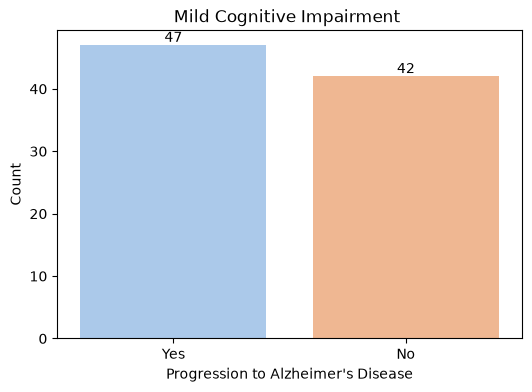

In [18]:
histogram_totals(totals=totals, title="Mild Cognitive Impairment ",xlabel="Progression to Alzheimer's Disease")

In [19]:
overlap_yes = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))


Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


In [20]:
df[df['Diagnostic'] == "Alzheimer's Disease"]

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months)
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
99,100,Alzheimer's Disease,Female,79,19,395.0,377.0,54.8,No,NaN,NaN
100,101,Alzheimer's Disease,Female,71,28,556.0,257.0,48.1,Yes,NaN,NaN
101,102,Alzheimer's Disease,Female,70,25,354.0,312.0,53.8,Yes,NaN,NaN
102,103,Alzheimer's Disease,Male,79,25,755.0,685.0,86.3,No,NaN,NaN


In [85]:
overlap_yes = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


## Key Observation


There are no patients who's Diagnostic is 'Alzheimer's Disease' or 'Control' "Progression to Alzheimer's Disease"

Therefore are two we will only consider Diagnostic "Mild Cognitive Impairment" and "Progression to Alzheimer's Disease" Yes or No

In [23]:
df.isna().sum()

Sample                                  0
Diagnostic                              0
Sex                                     0
Age                                     0
MMSE                                    0
CSF Amyloid (pg/mL)                    14
CSF Total tau (pg/mL)                  14
CSF Phosphorylated tau (pg/mL)         14
APOE4                                   3
Progression to Alzheimer's Disease    123
Progression time (months)             165
dtype: int64

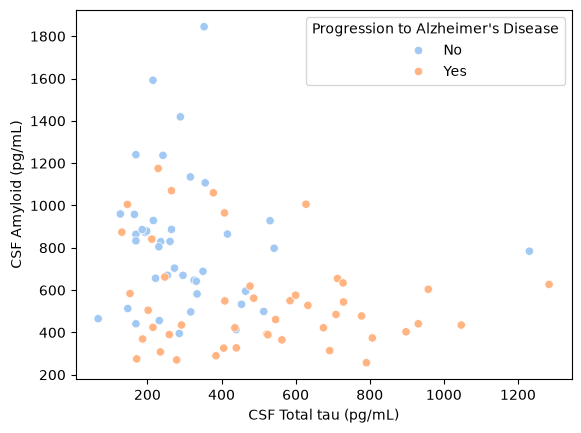

In [24]:
sns.scatterplot(data = df, x='CSF Total tau (pg/mL)', y='CSF Amyloid (pg/mL)', hue="Progression to Alzheimer's Disease")
plt.savefig(f"images/total_tau", dpi=300, bbox_inches="tight")
plt.show()

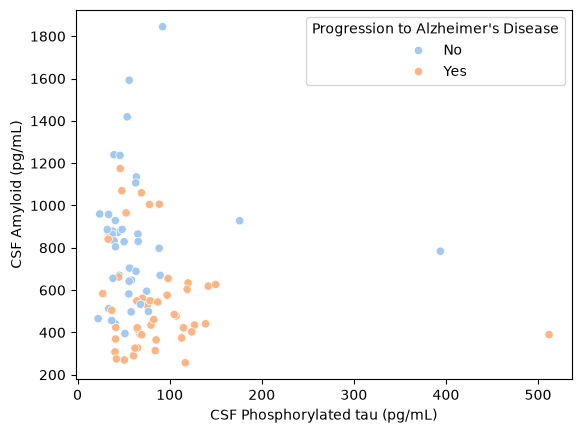

In [25]:

sns.scatterplot(data = df, x='CSF Phosphorylated tau (pg/mL)', y='CSF Amyloid (pg/mL)', hue="Progression to Alzheimer's Disease")
plt.savefig(f"images/amyloid_tau", dpi=300, bbox_inches="tight")
plt.show()

# Determine the best parameters
### Load the data, taking care of Nan values
### 

We have a problem, some of the Mild Cognitive Impairments have Nan values. So we are going to replace the Nan values with the most common value or mode which is 'No'

# The best parameters


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

In [25]:
import pandas as pd

# 1. Load data, keep only patients with a known outcome (MCI patients)
df = pd.read_csv('data/plasma_lipidomics.csv')
mci = df[df["Progression to Alzheimer's Disease"].notna()].copy()

# 2. Fill missing numeric values with the column median
numeric_cols = ['Age', 'MMSE', 'CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)',
                 'CSF Phosphorylated tau (pg/mL)']

for col in numeric_cols:
    median_val = mci[col].median()
    mci[col] = mci[col].fillna(median_val)

# 3. Fill missing categorical values with the most common value
mode_val = mci['APOE4'].mode()[0]
mci['APOE4'] = mci['APOE4'].fillna(mode_val)

# 4. Convert categorical text columns to numeric (0/1)
mci['Sex'] = (mci['Sex'] == 'Male').astype(int)          # Male=1, Female=0
mci['APOE4'] = (mci['APOE4'] == 'Yes').astype(int)        # carries APOE4 allele=1, no=0
mci['Target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)

# 5. Final feature set + target
feature_cols = numeric_cols + ['Sex', 'APOE4']
X = mci[feature_cols]
y = mci['Target']

In [47]:
bfrom sklearn.metrics import precision_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

def evaluate_performance(terms, X, y):
    #  5-fold cross-validation 
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])

    y_pred = cross_val_predict(model, X, y, cv=cv, method='pict')
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

    #  Confusion matrix 
    cm = confusion_matrix(y, y_pred, labels=[0, 1])

    #  Extract metrics 
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y, y_pred)
    accuracy = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_proba)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

    return {
        'features': terms,
        'n_features': len(terms),
        'accuracy': accuracy,b
        'precision': precision,
        'auc': auc,
        'false_negatives': fn,
        'false_negative_rate': fnr,
    }

In [ ]:
def evaluate_performance(terms, X, y):
    # terms: a list of strings describing which features/predictors are being used
    #        (just used for labeling the printout, doesn't affect the model)
    # X: your feature matrix (rows = patients, columns = predictor variables)
    # y: your target/label vector (0 = no progression, 1 = progressed to Alzheimer's)

    # ---- 5-fold cross-validation, out-of-fold predictions ----

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # This creates a "recipe" for splitting the data into 5 folds (chunks).
    # n_splits=5         -> split data into 5 roughly equal parts
    # StratifiedKFold    -> special version of KFold that makes sure each of the
    #                       5 folds has roughly the same % of class 0 vs class 1
    #                       as the full dataset. Important because progression
    #                       cases are probably rarer than non-progression cases,
    #                       and you don't want a fold that accidentally has zero
    #                       positive cases in it.
    # shuffle=True       -> randomly shuffle the data before splitting into folds
    #                       (otherwise it would just chop the data in the order
    #                       it appears, which could be biased e.g. if sorted by
    #                       date or patient ID)
    # random_state=42    -> fixes the "random seed" so the shuffle is the same
    #                       every time you run this -> reproducible results

    model = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    # This bundles TWO steps into a single object called `model`, so that
    # whenever `model` is "fit" or used to "predict", both steps run in order:
    #
    # Step 1 - 'sc': StandardScaler()
    #   Rescales every feature to have mean 0 and standard deviation 1.
    #   Logistic regression is sensitive to the scale of input features,
    #   so this puts all predictors on equal footing.
    #
    # Step 2 - 'clf': LogisticRegression(max_iter=1000)
    #   The actual model that learns to predict progression (0 or 1).
    #   max_iter=1000 just gives the optimizer more attempts to converge
    #   on a solution (default is 100, which sometimes isn't enough).
    #
    # Why bundle them in a Pipeline instead of doing them separately?
    # Because during cross-validation, the scaler must be fit ONLY on the
    # training folds each round, never on the test fold. If you scaled the
    # whole dataset once at the top of the script, information from the
    # test folds would "leak" into the training process, making the
    # evaluation overly optimistic. Pipeline handles this correctly and
    # automatically for every fold.

    y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')
    # This runs the ENTIRE 5-fold cross-validation procedure:
    #   Round 1: train `model` on folds 2,3,4,5 -> predict on fold 1
    #   Round 2: train `model` on folds 1,3,4,5 -> predict on fold 2
    #   Round 3: train `model` on folds 1,2,4,5 -> predict on fold 3
    #   Round 4: train `model` on folds 1,2,3,5 -> predict on fold 4
    #   Round 5: train `model` on folds 1,2,3,4 -> predict on fold 5
    #
    # method='predict' means: at each round, after fitting the model on
    # the training folds, call model.predict() on the held-out test fold.
    # .predict() returns a hard class label: 0 or 1.
    #
    # The results from all 5 rounds get stitched back together in the
    # original order, so y_pred is one array, same length as y, where
    # every single value is a prediction made by a model that NEVER saw
    # that particular row during training. That's the "honest" /
    # "out-of-fold" part - no data point is ever evaluated by a model
    # that was trained on it.

    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    # This repeats the EXACT SAME 5-fold procedure again (same folds,
    # since `cv` has random_state=42, so splits are identical to above).
    # The only difference: method='predict_proba' means at each round we
    # call model.predict_proba() instead of model.predict().
    #
    # .predict_proba() returns TWO probabilities per row:
    #   column 0 -> probability of class 0 (no progression)
    #   column 1 -> probability of class 1 (progression)
    #   (these two columns always add up to 1.0)
    #
    # [:, 1]  -> slice syntax meaning "give me all rows, but only column 1"
    #            so we keep just the probability of progression (class 1)
    #            and discard the probability of no-progression column.
    #
    # Why do we need this AS WELL as y_pred?
    # y_pred only tells us the model's final yes/no decision (using a
    # 0.5 probability cutoff by default). y_proba tells us HOW CONFIDENT
    # the model was. This matters for computing AUC (below), which checks
    # how well the model ranks patients from least-to-most likely to
    # progress, across every possible cutoff threshold - not just 0.5.
    #
    # Downside: because this calls cross_val_predict a second time, the
    # model is trained from scratch all over again (10 total model fits
    # instead of 5) - a bit wasteful, but harmless.

    # ---- Confusion matrix ----

    terms = ' '.join(terms)
    # Converts the list of feature-name strings into one single string,
    # joined by spaces, purely so it can be printed nicely below.
    # e.g. ['age', 'MMSE', 'APOE4'] -> 'age MMSE APOE4'

    print(f"Predicing 'Progression to Alzheimer's Disease' from {terms}\n")
    # Just prints a header describing what's being predicted and from what
    # features. (Typo: "Predicing" should be "Predicting", but cosmetic only.)

    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    # Builds a 2x2 grid comparing actual labels (y) vs predicted labels
    # (y_pred). labels=[0, 1] fixes the row/column order so 0 always comes
    # before 1. The grid looks like:
    #
    #                  Pred: No   Pred: Yes
    #   Actual: No      TN          FP
    #   Actual: Yes     FN          TP
    #
    # TN = true negative, FP = false positive,
    # FN = false negative, TP = true positive

    print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
    # Wraps that raw 2x2 numpy array in a pandas DataFrame purely so it
    # prints with readable row/column labels instead of bare numbers.

    # ---- Precision, recall, F1, accuracy, AUC ----

    print(classification_report(y, y_pred, target_names=['No progression', 'Progressed'], digits=3))
    # Auto-generates a text report with, for each class:
    #   precision - of everyone predicted positive, what % actually were?
    #   recall    - of everyone actually positive, what % did we catch?
    #   f1-score  - harmonic mean of precision and recall (balances both)
    #   support   - how many actual samples of that class exist
    # digits=3 just controls how many decimal places to show.

    print('Accuracy:', accuracy_score(y, y_pred))
    # Overall % of predictions (y_pred) that exactly matched the truth (y).
    # Can be misleading if classes are imbalanced (e.g. if only 5% of
    # patients progress, predicting "No" for everyone gives 95% accuracy
    # while being useless) - that's why the other metrics matter too.

    print('AUC:', roc_auc_score(y, y_proba))
    # Area Under the ROC Curve. Uses y_proba (the continuous probabilities),
    # NOT y_pred. Measures how well the model ranks progressing patients
    # as more likely to progress than non-progressing patients, averaged
    # across every possible probability cutoff - not just the default 0.5.
    # Score interpretation:
    #   1.0 = perfect ranking
    #   0.5 = no better than random guessing
    #   <0.5 = worse than random (model is systematically backwards)

In [49]:
bimport itertools

feature_list = list(X.columns)
all_combos = []
for r in range(1, len(feature_list) + 1):
    all_combos.extend(itertools.combinations(feature_list, r))

results = []
for combo in all_combos:
    cols = list(combo)
    result = evaluate_performance(cols, X[cols], y)
    results.append(result)

results_df = pd.DataFrame(results)

# ---- Filter: FNR <= 0.20, sort by accuracy desc, AUC as tiebreaker ----
best_df = (
    results_df[results_df['false_negative_rate'] <= 0.20]
    .sort_values(by=['accuracy', 'auc'], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"{len(best_df)} of {len(results_df)} combinations meet the FNR <= 0.20 threshold\n")
print(best_df.head(10))

8 of 127 combinations meet the FNR <= 0.20 threshold

                                            features  n_features  accuracy  \
0  [CSF Amyloid (pg/mL), CSF Phosphorylated tau (...           2  0.730337   
1  [CSF Amyloid (pg/mL), CSF Phosphorylated tau (...           3  0.719101   
2                              [CSF Amyloid (pg/mL)]           1  0.719101   
3                         [Age, CSF Amyloid (pg/mL)]           2  0.719101   
4                         [CSF Amyloid (pg/mL), Sex]           2  0.719101   
5                    [Age, CSF Amyloid (pg/mL), Sex]           3  0.719101   
6  [Age, CSF Amyloid (pg/mL), CSF Phosphorylated ...           3  0.707865   
7  [Age, CSF Amyloid (pg/mL), CSF Phosphorylated ...           4  0.707865   

   precision       auc  false_negatives  false_negative_rate  
0   0.709091  0.779382                8             0.170213  
1   0.696429  0.771023                8             0.170213  
2   0.696429  0.751013                8             0.

In [57]:
best_df.columns

Index(['features', 'n_features', 'accuracy', 'precision', 'auc',
       'false_negatives', 'false_negative_rate'],
      dtype='str')

In [58]:
best = best_df.iloc[0]

In [61]:
best.features

['CSF Amyloid (pg/mL)', 'CSF Phosphorylated tau (pg/mL)']

In [62]:
best.T

features               [CSF Amyloid (pg/mL), CSF Phosphorylated tau (...
n_features                                                             2
accuracy                                                        0.730337
precision                                                       0.709091
auc                                                             0.779382
false_negatives                                                        8
false_negative_rate                                             0.170213
Name: 0, dtype: object

# best classification algorithm

In [67]:
from sklearn.metrics import precision_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import pandas as pd

def evaluate_pipeline(terms, X, y, model, verbose=False):
    # ---- 5-fold cross-validation, honest out-of-fold predictions ----
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

    # ---- Confusion matrix ----
    cm = confusion_matrix(y, y_pred, labels=[0, 1])

    if verbose:
        display_terms = ' '.join(terms)
        print(f"Predicting 'Progression to Alzheimer's Disease' from {display_terms}\n")
        print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
        print(classification_report(y, y_pred, target_names=['No progression', 'Progressed'], digits=3))
        print('Accuracy:', accuracy_score(y, y_pred))
        print('AUC:', roc_auc_score(y, y_proba))

    # ---- Extract metrics ----
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y, y_pred)
    accuracy = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_proba)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

    return {
        'features': terms,
        'n_features': len(terms),
        'accuracy': accuracy,
        'precision': precision,
        'auc': auc,
        'false_negatives': fn,
        'false_negative_rate': fnr,
    }

In [68]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM (RBF)':            Pipeline([('sc', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors':  Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier())]),
    'LDA':                  Pipeline([('sc', StandardScaler()), ('clf', LinearDiscriminantAnalysis())]),
    'Naive Bayes':          Pipeline([('sc', StandardScaler()), ('clf', GaussianNB())]),
}

best_features = ['CSF Amyloid (pg/mL)', 'CSF Phosphorylated tau (pg/mL)']
X_best = X[best_features]

model_results = []
for name, model in models.items():
    result = evaluate_pipeline(best_features, X_best, y, model)
    result['model'] = name
    model_results.append(result)

model_results_df = pd.DataFrame(model_results)

# ---- Filter: FNR <= 0.20, sort by accuracy desc, AUC as tiebreaker ----
best_models_df = (
    model_results_df[model_results_df['false_negative_rate'] <= 0.20]
    .sort_values(by=['accuracy', 'auc'], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"{len(best_models_df)} of {len(model_results_df)} models meet the FNR <= 0.20 threshold\n")
print(best_models_df[['model', 'accuracy', 'precision', 'auc', 'false_negatives', 'false_negative_rate']])

3 of 7 models meet the FNR <= 0.20 threshold

                 model  accuracy  precision       auc  false_negatives  \
0  Logistic Regression  0.730337   0.709091  0.779382                8   
1                  LDA  0.707865   0.684211  0.779382                8   
2          Naive Bayes  0.696629   0.672414  0.790780                8   

   false_negative_rate  
0             0.170213  
1             0.170213  
2             0.170213  


In [69]:
## logistic regression

In [70]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import make_scorer, fbeta_score, precision_score, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

best_features = ['CSF Amyloid (pg/mL)', 'CSF Phosphorylated tau (pg/mL)']
X_best = X[best_features]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])

# Modest grid given the small sample size (89 patients)
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l2'],
    'clf__class_weight': [None, 'balanced'],
}

f2_scorer = make_scorer(fbeta_score, beta=2)

scoring_options = {
    'recall': 'recall',
    'f2': f2_scorer,
}

def run_grid_search(scoring_name, scoring):
    grid = GridSearchCV(pipe, param_grid, scoring=scoring, cv=cv, n_jobs=1)
    grid.fit(X_best, y)

    best_model = grid.best_estimator_

    # Evaluate the winning hyperparameters with honest out-of-fold predictions
    y_pred = cross_val_predict(best_model, X_best, y, cv=cv, method='predict')
    y_proba = cross_val_predict(best_model, X_best, y, cv=cv, method='predict_proba')[:, 1]

    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

    return {
        'scoring': scoring_name,
        'best_params': grid.best_params_,
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred),
        'auc': roc_auc_score(y, y_proba),
        'false_negatives': int(fn),
        'false_negative_rate': fnr,
    }

results = [run_grid_search(name, scoring) for name, scoring in scoring_options.items()]
comparison_df = pd.DataFrame(results)
print(comparison_df)

  scoring                                        best_params  accuracy  \
0  recall  {'clf__C': 0.01, 'clf__class_weight': None, 'c...  0.595506   
1      f2  {'clf__C': 10, 'clf__class_weight': None, 'clf...  0.741573   

   precision       auc  false_negatives  false_negative_rate  
0   0.579710  0.777356                7             0.148936  
1   0.722222  0.776849                8             0.170213  


F2 wins 
'clf', LogisticRegression(C=10, class_weight=None, penalty='l2', max_iter=1000

## Train the model

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, roc_auc_score
)
import pandas as pd

best_features = ['CSF Amyloid (pg/mL)', 'CSF Phosphorylated tau (pg/mL)']
X_best = X[best_features]

# ---- Stratified train/test split (80/20), preserves class balance ----
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train size: {len(X_train)}  ({y_train.sum()} Yes / {len(y_train) - y_train.sum()} No)")
print(f"Test size:  {len(X_test)}  ({y_test.sum()} Yes / {len(y_test) - y_test.sum()} No)")

# ---- Build and fit the final model ----
final_model = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(C=10, class_weight=None, penalty='l2', max_iter=1000))
])

final_model.fit(X_train, y_train)

# ---- Evaluate on the held-out test set ----
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
print(classification_report(y_test, y_pred, target_names=['No progression', 'Progressed'], digits=3))

tn, fp, fn, tp = cm.ravel()
fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

test_result = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_proba),
    'false_negatives': int(fn),
    'false_negative_rate': fnr,
}
print(test_result)

Train size: 71  (37 Yes / 34 No)
Test size:  18  (10 Yes / 8 No)
             Pred: No  Pred: Yes
Actual: No          6          2
Actual: Yes         2          8
                precision    recall  f1-score   support

No progression      0.750     0.750     0.750         8
    Progressed      0.800     0.800     0.800        10

      accuracy                          0.778        18
     macro avg      0.775     0.775     0.775        18
  weighted avg      0.778     0.778     0.778        18

{'accuracy': 0.7777777777777778, 'precision': 0.8, 'auc': 0.85, 'false_negatives': 2, 'false_negative_rate': np.float64(0.2)}


## The model

In [72]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

best_features = ['CSF Amyloid (pg/mL)', 'CSF Phosphorylated tau (pg/mL)']
X_best = X[best_features]

# ---- Build and fit on the FULL dataset (all 89 patients) ----
deployable_model = Pipeline([
    ('sc', StandardScaler()),
    ('clf', LogisticRegression(C=10, class_weight=None, penalty='l2', max_iter=1000))
])

deployable_model.fit(X_best, y)

# ---- Save to disk ----
joblib.dump(deployable_model, 'alzheimers_progression_model.joblib')
print("Model saved to alzheimers_progression_model.joblib")

# ---- Also save the feature list, since the model needs columns in this exact order ----
joblib.dump(best_features, 'alzheimers_progression_model_features.joblib')b

Model saved to alzheimers_progression_model.joblib


['alzheimers_progression_model_features.joblib']

# Load the Model

In [73]:
import joblib
import pandas as pd

model = joblib.load('alzheimers_progression_model.joblib')
features = joblib.load('alzheimers_progression_model_features.joblib')

# new_patients must be a DataFrame with the same columns, in the same order
def predict_progression(new_patients_df):
    X_new = new_patients_df[features]
    predictions = model.predict(X_new)
    probabilities = model.predict_proba(X_new)[:, 1]
    return pd.DataFrame({
        'predicted_progression': predictions,
        'progression_probability': probabilities
    }, index=new_patients_df.index)

# example:
# results = predict_progression(new_patients_df)

In [74]:
import pandas as pd

feature_cols = ['CSF Amyloid (pg/mL)', 'CSF Phosphorylated tau (pg/mL)']

# Raw array: [amyloid, p-tau] per patient
test_array = [
    [368.2, 119.2],   # High-risk profile
    [604.0, 63.5],    # Median profile
    [1062.0, 37.1],   # Low-risk profile
    [257.0, 512.0],   # Extreme AD-like (observed min amyloid + max p-tau)
    [1845.0, 22.4],   # Extreme low-risk (observed max amyloid + min p-tau)
]

test_labels = [
    'High-risk profile',
    'Median profile',
    'Low-risk profile',
    'Extreme AD-like',
    'Extreme low-risk',
]

test_patients = pd.DataFrame(test_array, columns=feature_cols, index=test_labels)
test_patients

,CSF Amyloid (pg/mL),CSF Phosphorylated tau (pg/mL)
High-risk profile,368.2,119.2
Median profile,604.0,63.5
Low-risk profile,1062.0,37.1
Extreme AD-like,257.0,512.0
Extreme low-risk,1845.0,22.4


In [76]:




model = joblib.load('alzheimers_progression_model.joblib')  # adjust path if needed

predictions = model.predict(test_patients)
probabilities = model.predict_proba(test_patients)[:, 1]

results = test_patients.copy()
results['predicted_progression'] = predictions
results['progression_probability'] = probabilities.round(3)

results

IndexError: list index out of range

                                                   predicted_progression  \
High-risk profile                                                      1   
Median profile                                                         1   
Low-risk profile                         patients                      0   
Extreme AD-like               CSF Amyloid (pg/mL)                      1   
Extreme low-risk   CSF Phosphorylated tau (pg/mL)                      0   

                   progression_probability  
High-risk profile                    0.808  
Median profile                       0.564  
Low-risk profile                     0.175  
Extreme AD-like                      0.985  
Extreme low-risk                     0.011  